### Setup
In this section I import the Python libraries used throughout the analysis.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In this step, I load the dataset containing the LSOA population data for England.

In [58]:
england_population = pd.read_csv('LSOA_data.csv')

### Column selection and proportions
In this step, I first exclude the non-age columns (such as codes, names and the overall total) to focus only on the 18 age ranges. I then calculate the total population for each age group across all LSOAs in England and show these totals as proportions of England's population. 

In [59]:
age_columns = england_population.iloc[:, 5:]
england_age_total = age_columns.sum()
england_age_prop = england_age_total / england_age_total.sum()


### England_age_prop bar chart
In this step, I create a bar chart to illustrate the age distribution in England. Age groups are shown on the x-axis, and the y-axis represents the proportion of each group in the total population. To make the chart more understandable, I add titles to axes and the chart using functions such as `plt.xlabel`, `plt.ylabel`, and `plt.title`.  

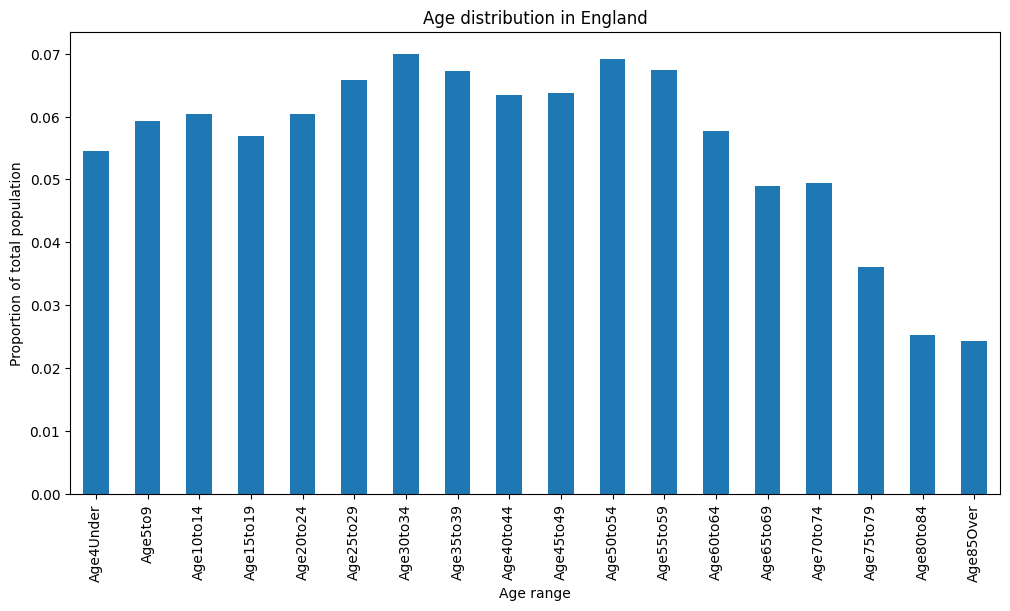

In [60]:
england_age_prop.plot(kind='bar', figsize=(12,6))
plt.xlabel('Age range')
plt.ylabel('Proportion of total population')
plt.title('Age distribution in England')
plt.show()

### LSOA selection
In this step, I use the `loc` function to select three LSOAs (Bury, Dorset, Birmingham) from the dataset based on their LSOA codes. 

In [61]:
bury = england_population.loc[england_population['LSOACode'] == 'E01005044']
dorset = england_population.loc[england_population['LSOACode'] == 'E01020395']
birm = england_population.loc[england_population['LSOACode'] == 'E01009136']

### Column selection
In this step, I repeat the process from england_population using the iloc function, selecting only the age groups for each LSOA. This leaves the columns needed for comparison in the bar chart. 

In [62]:
bury_age = bury.iloc[:, 5:]
dorset_age = dorset.iloc[:, 5:]
birm_age = birm.iloc[:, 5:]

### Proportion calculation
In this step, I calculate the proportions for each LSOA by dividing the age groups by the total population. This allows me to compare the age distribution of each LSOA with England without being affected by differences in total population size.

In [63]:
bury_prop = bury_age / bury['Total'].iloc[0]
dorset_prop = dorset_age / dorset['Total'].iloc[0]
birm_prop = birm_age / birm['Total'].iloc[0]

### Combining Data
In this step, I combine the age group proportions for England and the three LSOAs into a single DataFrame, so that the data can be shown in the same table and easily compared in a bar chart. 

In [64]:
plt_df = pd.DataFrame({
    'AgeRange': england_age_prop.index,
    'England': england_age_prop.values,
    'Bury': bury_prop.values[0],
    'Dorset': dorset_prop.values[0],
    'Birmingham': birm_prop.values[0]
})

### Creating bar chart
In this step, I create a grouped bar chart using the DataFrame to compare England and the three LSOAs. The x-axis shows the age groups, and the y-axis shows the proportions for each area. 


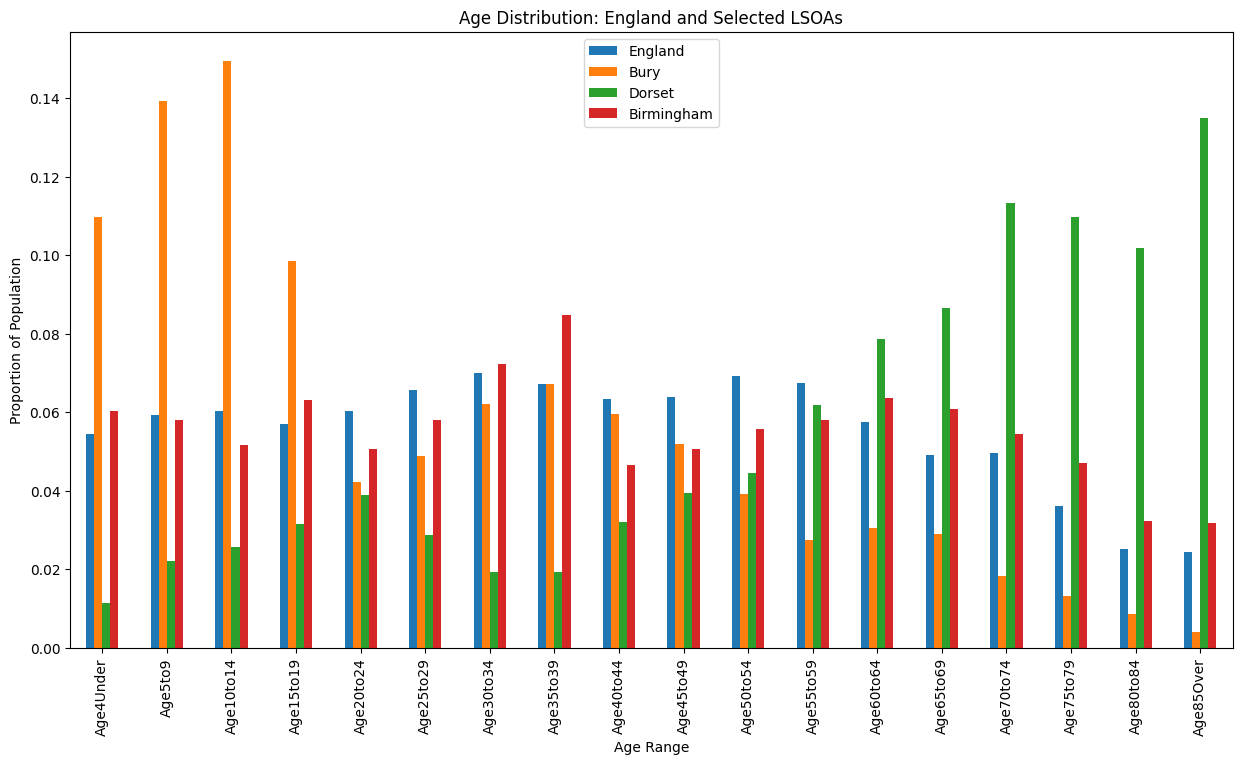

In [65]:
ax = plt_df.plot(kind='bar', x='AgeRange', y=['England', 'Bury', 'Dorset', 'Birmingham'], figsize=(15,8))

plt.xlabel('Age Range')
plt.ylabel('Proportion of Population')
plt.title('Age Distribution: England and Selected LSOAs')
plt.show()

### Analysis of the Age Distribution
 
An examination of the bar chart shows that England has a more balanced and proportionate age distribution. However, the three selected LSOAs do not fully reflect this pattern. Among them, Birmingham appears to be the closest to the national distribution. 

Bury: The proportion of the population aged 0-19 is higher than the national average. This may indicate a higher concentration of families with children. Families may be drawn to the area because of its child-friendly parks, schools, and affordable housing.

Dorset: The proportion of the population aged over 60 is significantly higher than the England average. This may be explained by the area being a popular choice for retirees. In addition, the region's strong healthcare services attract older residents, while limited job opportunities may encourage younger people to move away.

Birmingham: This area has the age distribution most similar to the national average. However, the proportion of young adults (particulary those aged 20-39) is slightly higher than the national average. This may be due to Birmingham being a large city with a central location, strong transport links, and an appeal to young people through its universities, job opportunities, and entertainment options.

### Younger and Older Proportions
In this step, I add two new columns to the DataFrame, younger_prop and older_prop. I calculated these columns by dividing the sum of the respective age groups by the total population in each LSOA.

In [66]:
england_population['younger_prop'] = england_population.iloc[:, 5:9].sum(axis=1)/england_population['Total']
england_population['older_prop'] = england_population.iloc[:, -5:].sum(axis=1) / england_population['Total']

### Note
Before calculating the median age, I checked the column names to identify the coreect index range for the age groups.

In [67]:
england_population.columns

Index(['LSOAName', 'LSOACode', 'PartOfCode', 'PartOfName', 'Total',
       'Age4Under', 'Age5to9', 'Age10to14', 'Age15to19', 'Age20to24',
       'Age25to29', 'Age30to34', 'Age35to39', 'Age40to44', 'Age45to49',
       'Age50to54', 'Age55to59', 'Age60to64', 'Age65to69', 'Age70to74',
       'Age75to79', 'Age80to84', 'Age85Over', 'younger_prop', 'older_prop'],
      dtype='object')

### Calculating Median Age
In this step, I calculate the median age for each LSOA by following the provided pseudocode. I first calculate the cumulative proportions, then determine the age group where the 50th percentile is reached, and finally interpolate within that range to estimate the median age. In the code, I select by position using `iloc`. I also define the lower bounds of each age range through an `ages` list.



In [68]:
def findMedian(counts):
    ages = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85]
    cumul_fract = np.cumsum(counts) / counts.sum()
    index = 0
    while cumul_fract.iloc[index] < 0.5:
        index += 1
    prev_fract = 0
    if index > 0:
        prev_fract = cumul_fract.iloc[index-1]
    
    remaining_fract = 0.5 - prev_fract
    fract_increase = cumul_fract.iloc[index] - prev_fract

    median_age = ages[index] + 5 * (remaining_fract / fract_increase)
    return median_age

england_population['median_age'] = england_population.iloc[:, 5:23].apply(findMedian, axis=1)

###  Statistical Summary
In this step, I use `describe()` function to show the summary statistics of the total population, younger and older proportions, and the median age.

In [69]:
england_population[['Total', 'younger_prop', 'older_prop', 'median_age']].describe()

,Total,younger_prop,older_prop,median_age
count,33755.000000,33755.000000,33755.000000,33755.000000
mean,1673.532543,0.227832,0.139125,42.032147
std,353.289631,0.055301,0.069085,7.782742
min,999.000000,0.018081,0.000142,14.530516
25%,1443.000000,0.192297,0.085965,36.128752
50%,1608.000000,0.223183,0.132482,41.460674
75%,1835.000000,0.258689,0.184009,47.821934
max,9900.000000,0.628793,0.550700,71.875000


### Histograms of Total Population, Younger Proportion, Older Proportionand Median Age
In this step, I create histograms to show the distributions of the total population, the younger and older proportions, and the median age across the LSOAs. I increase the number of bins to 50 and use a 2x2 layout to make the plots clearer and easier to compare. 

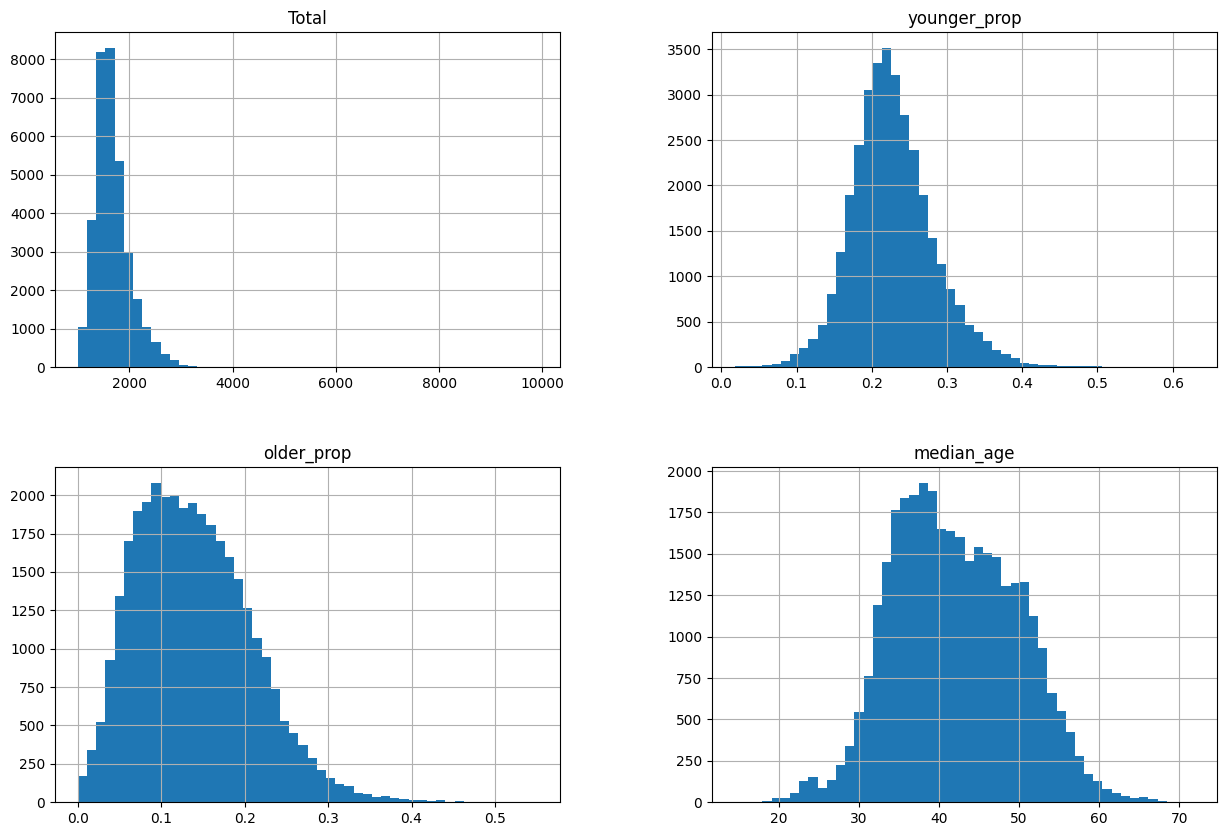

In [70]:
ax = england_population.hist(figsize=(15,10), column=['Total', 'younger_prop', 'older_prop', 'median_age'], bins=50, sharex=False, layout=(2,2))

### Analysis of the Histograms
An examination of the histograms shows that only a small number of LSOAs have very large populations, while the majority are concentrated at lower population levels. The proportion of younger residents is fairly consistent across LSOAs, typically ranging between 20% and 30%. The proportion of older residents is generally low, although in some ares it is noticeably higher. Finally, the median age histogram indicates that most LSOAs fall within the 35-50 age range, with only a few standing out as significantly younger or older. 


### Median age for the whole of England
In this step, I first calculate the total age distribution for England by adding the age groups across all LSOA's. This provides the total number of people in each age band. I then use this distribution to compute the cumulative totals and identify the age band containing the middle 50% of the population. Form this, Iderive the overall median age for England. 

In [71]:
england_overall = england_population.iloc[:,5:23].sum()
england_overall_median = findMedian(england_overall)
print('Median age for the whole of England:', england_median)

Median age for the whole of England: 40.4322611250074


### LSOAs Median Ages (50th percentile)
In this step, I use the median_age column, which contains the median ages previously calculated for each LSOA using the findMedian function. By ordering the values in this column and taking the middle one, I obtain the value that represents 50% of the LSOA median ages (lsoa_median).

In [72]:
lsoa_median = england_population['median_age'].median()
print('LSOAs median ages(50th percentile):', lsoa_median)

LSOAs median ages(50th percentile): 41.46067415730337


### Comparison of Median Ages
Comparing the results, the median age for England as a whole is about 40 years, while the median of the LSOA median ages is slightly higher at around 41.5 years. The small difference arises from the way the two figures are calculated. The national median age is population-weighted, meaning that areas with larger populations have a stronger influence on the result. By contrast, the distribution of LSOA median ages gives each area equal weight, regardless of population size. As a result, the two values are close, but not identical.


### Step 1 - Adding AreaType and Grouping the Data
In this step, Iadd the AreaType column by taking the first three characters of the PartOfCode variable. Then, I group the data by the AreaType column using the `groupby` function. 

In [73]:
england_population['AreaType'] = england_population['PartOfCode'].str[:3]
grouped = england_population.groupby('AreaType')

### Creating Boxplot of Median Age by Area Type
In this step, I use a boxplot to compare median age distributions across four different area types. The boxplot shows the median values and distributions side by side in a single graph, making it easy to see the differences between groups. Using a boxplot also makes it possible to clearly identify outliers, which helps to better understand the variation within each area type.

Text(0, 0.5, 'Median Age')

<Figure size 1000x600 with 0 Axes>

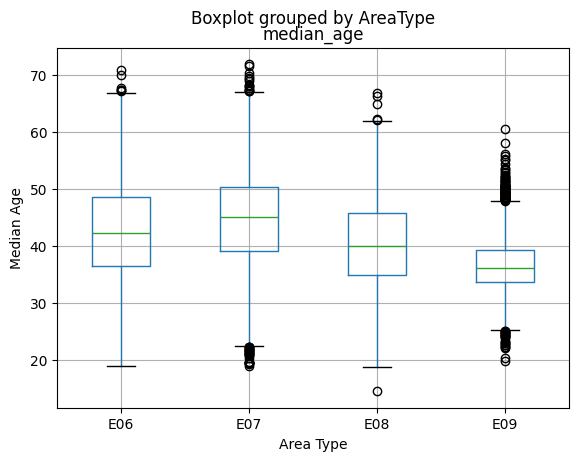

In [74]:
plt.figure(figsize=(10,6))
england_population.boxplot(column='median_age', by='AreaType')
plt.xlabel('Area Type')
plt.ylabel('Median Age')

### Comparison of Median Age Distributions by Area Type
The three area types (E06, E07, E08) have similar median ages, mostly in the 40-45 range. Among them, E07 is slightly higher, indicating that rural areas tend to have an older population, while E06 and E08 are closer to the middle of the range. In contrast, London boroughs (E09) show a noticeably lower median age. E09 also has numerous outliers, suggesting that the age distribution of London's LSOAs is more heterogeneous. 

### Scatter Plot of Younger vs Older Proportions
In this step, I create a scatter plot to examine the relationship between younger_porp (proportion of younger residents) aand older_prop (proportion of older residents). Each LSOA is represented as a point on the graph. I set the markers to be samll (s=5) and semi-transparent (alpha=0.3) to make the dense regions and the overall shape of the distribution clearer.

Text(0.5, 1.0, 'Scatter Plot of Younger vs Older Proportions by LSOA')

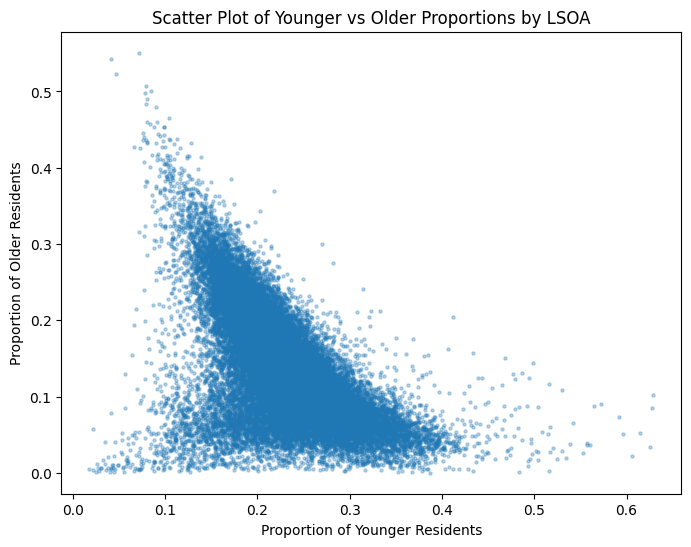

In [75]:
ax = england_population.plot.scatter(x='younger_prop', y='older_prop', s=5, alpha=0.3, figsize=(8,6))
plt.xlabel('Proportion of Younger Residents')
plt.ylabel('Proportion of Older Residents')
plt.title('Scatter Plot of Younger vs Older Proportions by LSOA')

### Scatter of Younger and Older Proportions
An examination of the scatter plot reveals that most LSOAs have young population proportion of 20-30% and an elderly population proportion of around 10%. This reflects the most common demographic structure. Some areas have very high young populations and low elderly populations, while others, conversely, have very high elderly populations.These extremes give the plot a roughly triangular shape. Overall, the majority of LSOAs are clustered in the central region. 

### Grouping LSOAs by Age Distribution
In this step, I classify each LSOA using the proportions of young and old residents. First, I define the `classify_area` function and evaluate each row (LSOA) individually, assigning it to one of four categories: Student Town (high proportion of young residents), Retirement Zone (high proportion of elderly residents), Working Class (low proportions of both young and elderly, mostly middle-aged), and Balanced (more typical distribution). I then summarize the number of LSOAs in each class using the `value_counts()` function. The threshold values (e.g., 35% for the young population and 10% for the elderly population) are selected based on the overall distribution of the scatter plot to roughly separate the extreme areas.


In [76]:
def classify_area(lsoa):
    if lsoa['younger_prop'] > 0.35 and lsoa['older_prop'] < 0.10:
        return 'Student Town'
    elif lsoa['older_prop'] > 0.20 and lsoa['younger_prop'] < 0.20:
        return 'Retirement Zone'
    elif lsoa['younger_prop'] < 0.20 and lsoa['older_prop'] < 0.10:
        return 'Working Class'
    else:
        return 'Balanced'

england_population['AreaClass'] = england_population.apply(classify_area, axis=1)
england_population['AreaClass'].value_counts()

AreaClass
Balanced           26193
Retirement Zone     5043
Working Class       1725
Student Town         794
Name: count, dtype: int64

### Pivot Table of LSOAs by Area Type and Class
In this step, I create a pivot table to group each LSOA by both AreaType (E06, E07, E08, E09) and AreaClass (Student Town, Retirement Zone, Working Class, Balanced). This table summarizes the number of LSOAs that fall into each class within each AreaType.

In [77]:
pivot = england_population.pivot_table(index='AreaType', columns='AreaClass', aggfunc='size')
print(pivot)

AreaClass  Balanced  Retirement Zone  Student Town  Working Class
AreaType                                                         
E06            6815             1461           201            350
E07            9438             2851            92            218
E08            5944              680           420            291
E09            3996               51            81            866


### Pivot Table Excluding Balanced
In this step, I create another pivot table similar to the previous one but exclude the 'Balanced' category using the `drop` function. This is because the next bar chart should focus only on the extreme categories (Student Town, Retirement Zone, Working Class).

In [78]:
pivot_no_balanced = england_population.pivot_table(index='AreaType', columns='AreaClass', aggfunc='size').drop(columns='Balanced')
print(pivot_no_balanced)

AreaClass  Retirement Zone  Student Town  Working Class
AreaType                                               
E06                   1461           201            350
E07                   2851            92            218
E08                    680           420            291
E09                     51            81            866


### Plotting the Bar Chart of Extreme Area Classes
In this step, I use a bar chart to visualize the number of LSOAs in each extreme class across the four different AreaTypes. 

<function matplotlib.pyplot.show(close=None, block=None)>

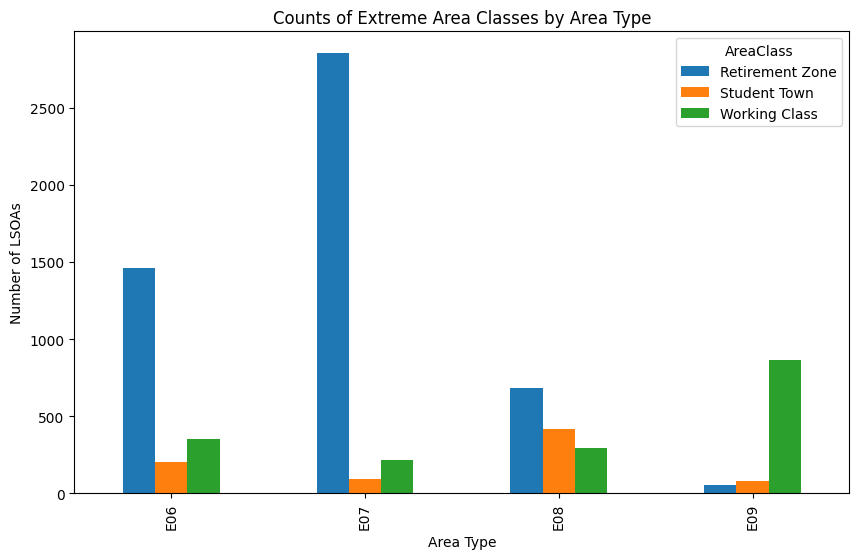

In [79]:
ax = pivot_no_balanced.plot(kind='bar', figsize=(10,6))
plt.xlabel('Area Type')
plt.ylabel('Number of LSOAs')
plt.title('Counts of Extreme Area Classes by Area Type')
plt.show

### Comparison of Area Classes Across Different Area Types
An examination of the graph reveals that the 'Retirement Zone' class, with its high concentration of elderly residents, is by far the most prevalent in E07 (non-metropolitan districts). The 'Working Class' category stands out in E09 (London boroughs). In E08 (metropolitan districts), the number of student-dense 'Student Town areas is higher than in other regions. Finally, in E06 (unitary authorities), both the 'Retirement Zone' and 'Working Class' categories are prominent, showing a more mixed distribution.